In [41]:
print ("Hello Bioinformatics!")

Hello Bioinformatics!


In [3]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.3 MB/s eta 0:00:00


In [42]:
from Bio import SeqIO
print("Biopython uploaded successfully!")

Biopython uploaded successfully!


In [43]:
fasta = """>Sequence_1
ATGCGTACGTAGCTAGCTAGCTAGCTAGCGCGCGATATAT
>Sequence_2
ATATATATGCGCGCGCGCGCGTTTTAAAAGGGCCC
>Sequence_3
GGGGCCCCAAAATTTTATATATATGCGCGCGCGC
"""

with open("sample.fasta", "w") as f:
    f.write(fasta)

print("sample.fasta created!")

sample.fasta created!


In [6]:
from Bio import SeqIO
records = list(SeqIO.parse("sample.fasta", "fasta"))
print(f"Total number of sequences: {len(records)}")
for record in records:
  print(record.id, len(record.seq))

Total number of sequences: 3
Sequence_1 40
Sequence_2 35
Sequence_3 34


In [7]:
for record in records:
  sequence = str(record.seq)
  g_count = sequence.count("G")
  c_count = sequence.count("C")
  gc_content = (g_count + c_count) / len(sequence) * 100
  print(f"{record.id}")
  print(f"Lenght: {len(sequence)}")
  print(f"GC_Content(%): %{gc_content:.2f}")
  print("-" * 30)


Sequence_1
Lenght: 40
GC_Content(%): %50.00
------------------------------
Sequence_2
Lenght: 35
GC_Content(%): %54.29
------------------------------
Sequence_3
Lenght: 34
GC_Content(%): %52.94
------------------------------


In [8]:
!pip install pandas

In [9]:
import pandas as pd
results = []
for record in records:
  sequence = str(record.seq)
  length = len(sequence)
  g_count = sequence.count("G")
  c_count = sequence.count("C")
  gc_content = (g_count + c_count) / length * 100
  results.append({
      "Sequence_ID": record.id,
      "Length": length,
      "GC_Content (%)": round(gc_content, 2)
  })
df = pd.DataFrame(results)
df


,Sequence_ID,Length,GC_Content (%)
0,Sequence_1,40,50.00
1,Sequence_2,35,54.29
2,Sequence_3,34,52.94


In [10]:
!pip install matplotlib

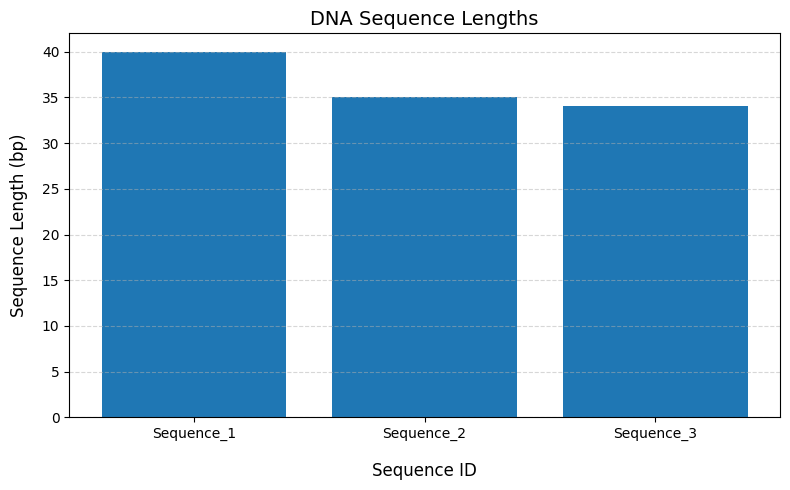

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df["Sequence_ID"], df["Length"])
plt.title("DNA Sequence Lengths", fontsize=14)
plt.xlabel("Sequence ID", fontsize=12, labelpad=15)
plt.ylabel("Sequence Length (bp)", fontsize=12, labelpad=10)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("sequence_length.png", dpi=300)

plt.show()

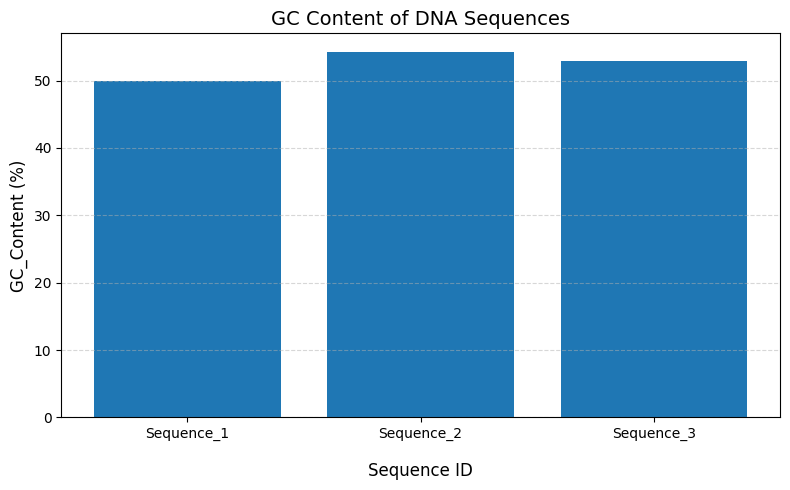

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df["Sequence_ID"], df["GC_Content (%)"])
plt.title("GC Content of DNA Sequences", fontsize=14)
plt.xlabel("Sequence ID", fontsize=12, labelpad=15)
plt.ylabel("GC_Content (%)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("gc_content.png", dpi=300)

plt.show()

In [13]:
average_length = df["Length"].mean()
average_gc = df["GC_Content (%)"].mean()

print(f"Average Sequence Length: {average_length:.2f} bp")
print(f"Average GC Content: {average_gc:.2f}%")

Average Sequence Length: 36.33 bp
Average GC Content: 52.41%


In [14]:
longest_sequence = df.loc[df["Length"].idxmax()]

print("Longest Sequence")
print(longest_sequence)

Longest Sequence
Sequence_ID       Sequence_1
Length                    40
GC_Content (%)          50.0
Name: 0, dtype: object


In [15]:
highest_gc = df.loc[df["GC_Content (%)"].idxmax()]

print("Sequence with the Highest GC Content")
print(highest_gc)

Sequence with the Highest GC Content
Sequence_ID       Sequence_2
Length                    35
GC_Content (%)         54.29
Name: 1, dtype: object


In [16]:
composition = []
for record in records:
  sequence = str(record.seq)
  composition.append({
      "Sequence_ID": record.id,
      "A": sequence.count("A"),
      "T": sequence.count("T"),
      "G": sequence.count("G"),
      "C": sequence.count("C")
  })
composition_df = pd.DataFrame(composition)
composition_df

,Sequence_ID,A,T,G,C
0,Sequence_1,10,10,11,9
1,Sequence_2,8,8,10,9
2,Sequence_3,8,8,9,9


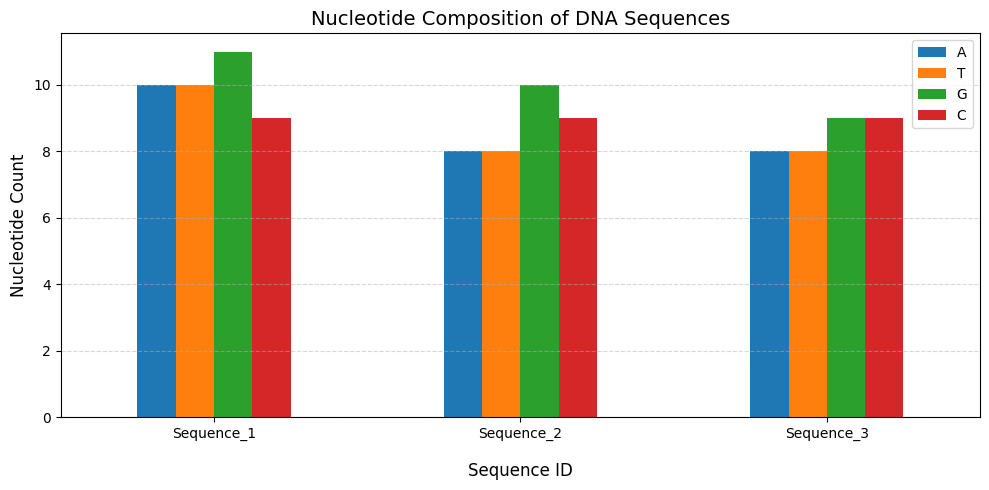

In [36]:
composition_df.set_index("Sequence_ID").plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Nucleotide Composition of DNA Sequences", fontsize=14)
plt.xlabel("Sequence ID", labelpad=15, fontsize=12)
plt.ylabel("Nucleotide Count", fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("nucleotide_composition.png", dpi=300)
plt.show()

In [18]:
def generate_report(df, composition_df):

  total_sequences = len(df)
  average_length = df["Length"].mean()
  average_gc = df["GC_Content (%)"].mean()

  longest_sequence = df.loc[df["Length"].idxmax(), "Sequence_ID"]
  shortest_sequence = df.loc[df["Length"].idxmin(), "Sequence_ID"]

  highest_gc = df.loc[df["GC_Content (%)"].idxmax(), "Sequence_ID"]
  lowest_gc = df.loc[df["GC_Content (%)"].idxmin(), "Sequence_ID"]

  print("=" * 50)
  print("DNA SEQUENCE ANALYSIS REPORT")
  print("=" * 50)

  print(f"Total Sequences: {total_sequences}")
  print(f"Average Sequence Length: {average_length:.2f} bp")
  print(f"Average GC Content: {average_gc:.2f}%")

  print()
  print(f"Longest Sequence: {longest_sequence}")
  print(f"Shortest Sequence: {shortest_sequence}")
  print(f"Highest GC Content: {highest_gc}")
  print(f"Lowest GC Content: {lowest_gc}")

  print()
  print("-" * 50)
  print("NUCLEOTIDE COMPOSITION")
  print("-" * 50)
  print(composition_df.to_string(index=False))

  print("=" * 50)


In [19]:
generate_report(df, composition_df)

DNA SEQUENCE ANALYSIS REPORT
Total Sequences: 3
Average Sequence Length: 36.33 bp
Average GC Content: 52.41%

Longest Sequence: Sequence_1
Shortest Sequence: Sequence_3
Highest GC Content: Sequence_2
Lowest GC Content: Sequence_1

--------------------------------------------------
NUCLEOTIDE COMPOSITION
--------------------------------------------------
Sequence_ID  A  T  G  C
 Sequence_1 10 10 11  9
 Sequence_2  8  8 10  9
 Sequence_3  8  8  9  9


In [22]:
composition_df.to_csv("sequence_length.csv", index=False)

In [23]:
composition_df.to_csv("gc_content.csv", index=False)

In [24]:
import os

os.makedirs("figures", exist_ok=True)

print("Figures folder created!")

Figures folder created!


In [25]:
import shutil

shutil.move("sequence_length.png", "figures/sequence_length.png")
shutil.move("gc_content.png", "figures/gc_content.png")
shutil.move(
    "nucleotide_composition.png",
    "figures/nucleotide_composition.png"
)

print("Figures moved successfully!")

Figures moved successfully!


In [26]:
df["AT_Content (%)"] = 100 - df["GC_Content (%)"]
df

,Sequence_ID,Length,GC_Content (%),AT_Content (%)
0,Sequence_1,40,50.00,50.00
1,Sequence_2,35,54.29,45.71
2,Sequence_3,34,52.94,47.06


In [27]:
print(df[["Sequence_ID", "GC_Content (%)", "AT_Content (%)"]])

  Sequence_ID  GC_Content (%)  AT_Content (%)
0  Sequence_1           50.00           50.00
1  Sequence_2           54.29           45.71
2  Sequence_3           52.94           47.06


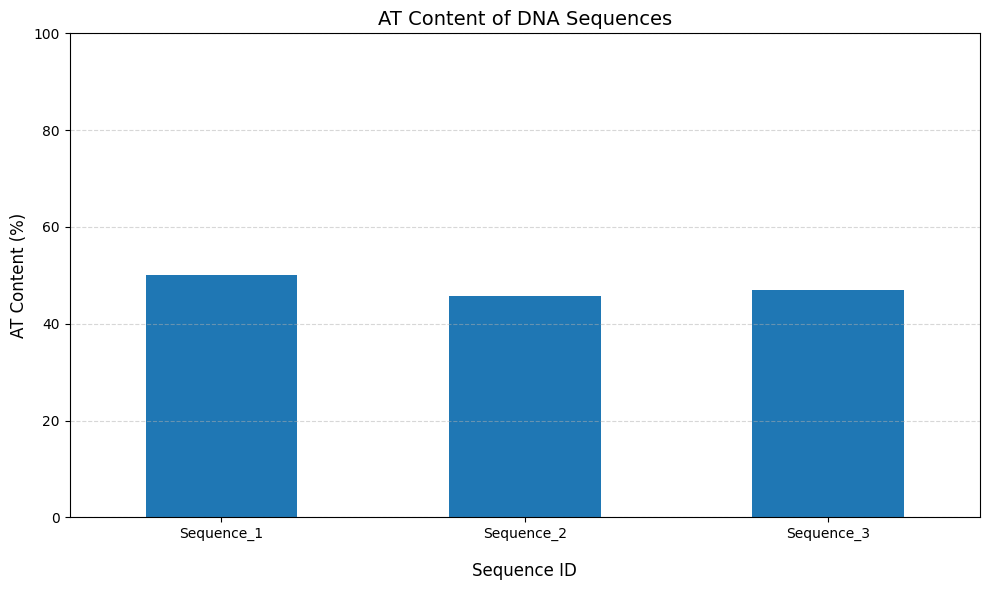

In [30]:
import matplotlib.pyplot as plt

df.plot(
    x="Sequence_ID",
    y="AT_Content (%)",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("AT Content of DNA Sequences", fontsize=14)
plt.xlabel("Sequence ID", labelpad=15, fontsize=12)
plt.ylabel("AT Content (%)", fontsize=12)

plt.xticks(rotation=0)

plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("at_content.png", dpi=300)

plt.show()

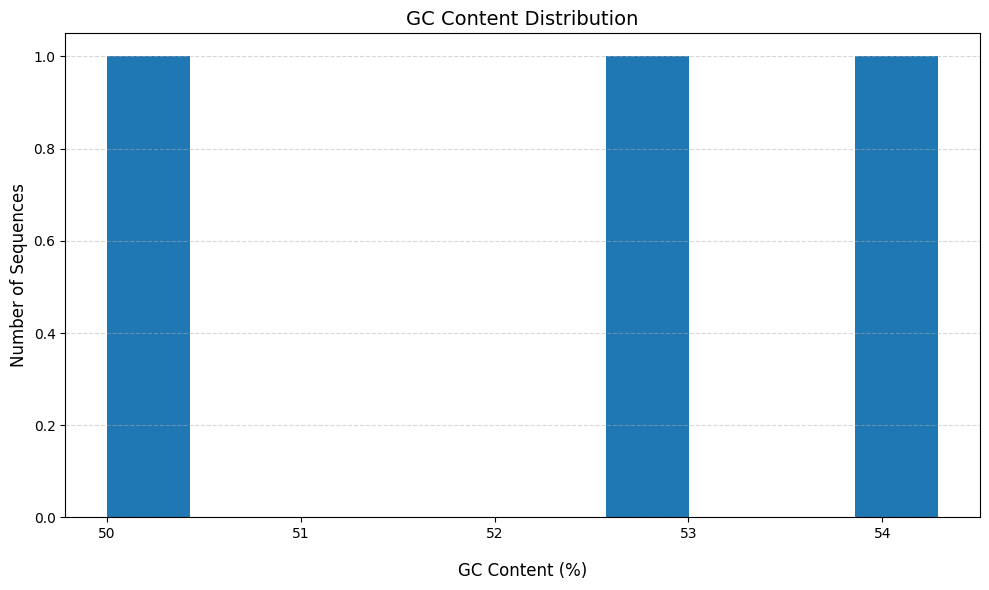

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    df["GC_Content (%)"],
    bins=10
)

plt.title("GC Content Distribution", fontsize=14)
plt.xlabel("GC Content (%)", labelpad=15, fontsize=12)
plt.ylabel("Number of Sequences", fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("gc_content_distribution.png", dpi=300)

plt.show()

In [33]:
df.to_csv("at_content.csv", index=False)


In [34]:
import os

os.makedirs("figures", exist_ok=True)

In [35]:
import shutil

shutil.move("at_content.png", "figures/at_content.png")
shutil.move(
    "gc_content_distribution.png",
    "figures/gc_content_distribution.png"
)

print("New figures moved successfully!")

New figures moved successfully!
